Most common lengths: [(7, 754), (8, 561), (6, 416), (9, 386), (10, 93)]


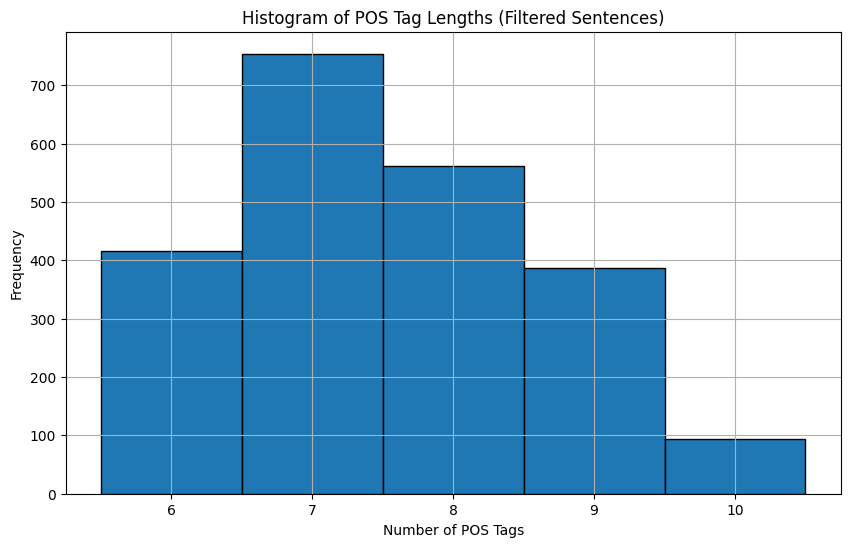

In [1]:
import matplotlib.pyplot as plt
from collections import Counter

# Your previous filtering code
path0 = './'
filename = 'syntax_mismatched_sentences.txt'
threshold = .45

data = []
lengths = []

with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 5:
            sentence1, sentence2, tags1, tags2, word_overlap = parts
            try:
                if (
                    float(word_overlap) < threshold and
                    len(tags1.split()) == len(tags2.split())
                ):
                    length = len(tags1.split())
                    lengths.append(length)
                    data.append((sentence1, sentence2, tags1, tags2, word_overlap))
            except ValueError:
                continue

# Count frequencies of lengths
length_counts = Counter(lengths)

# Print most common lengths
print("Most common lengths:", length_counts.most_common(10))

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=range(min(lengths), max(lengths) + 2), edgecolor='black', align='left')
plt.title("Histogram of POS Tag Lengths (Filtered Sentences)")
plt.xlabel("Number of POS Tags")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [2]:
with open(f"{path0}sentences0.txt", "w") as f1, \
    open(f"{path0}sentences1.txt", "w") as f2, \
    open(f"{path0}tags1.txt",        "w") as f3, \
    open(f"{path0}tags2.txt",        "w") as f4, \
    open(f"{path0}overlaps.txt",    "w") as f5:

    for s1, s2, tags1,tags2, word_overlap in data:
        f1.write(s1 + "\n")
        f2.write(s2 + "\n")
        f3.write(tags1 + "\n")
        f4.write(tags2 + "\n")
        f5.write(word_overlap + "\n")

In [6]:
# Map each unique length to a unique group ID
unique_lengths = sorted(set(lengths))
length_to_group_id = {length: idx for idx, length in enumerate(unique_lengths)}

# Generate group IDs for each line in the filtered data
group_ids = [length_to_group_id[length] for length in lengths]

# Save group IDs to file
with open("group_ids.txt", "w") as out_f:
    for gid in group_ids:
        out_f.write(f"{gid}\n")
